## imports

In [20]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:

from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


# agent and task

In [22]:
modelname = 'varyreward67noperoid'
iepoch=22


# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 333
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2

thismodel = f'seed{seed}_{modelname}_{iepoch}'
model = PPO.load(f'ycstore/{thismodel}')

# plot

color choice, gradient
better agent
axis, 
pick a better model

new plot, combine att and lick.



In [23]:
# collect trial data
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                              num_steps=100000, deterministic=True)
    return episode


with multiprocess.Pool(processes=6) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

In [24]:
# process the data. this is slow.
all_reward_res={} # k: v = foodreward idx: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


for episode in all_episode_data[:]:
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
 
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    else:
        lick_time_list.append(None)
    trial_len.append(len(episode['actions']))

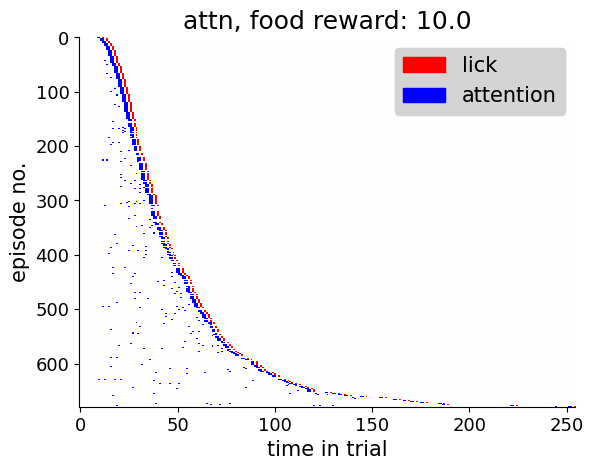

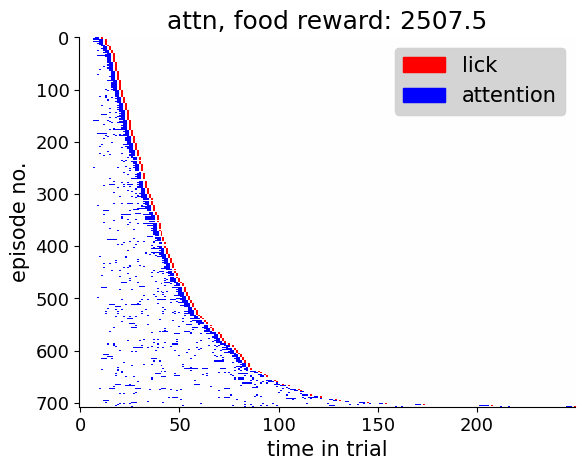

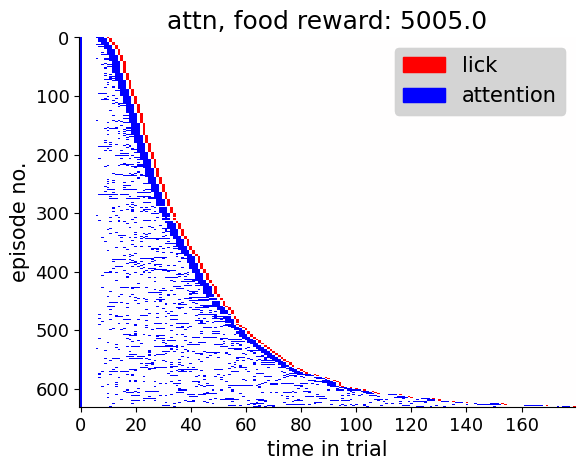

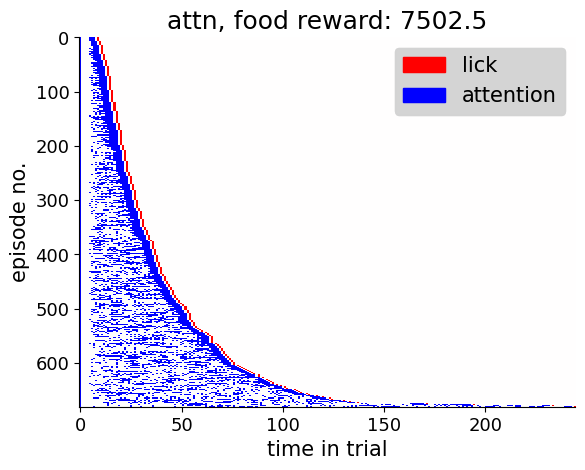

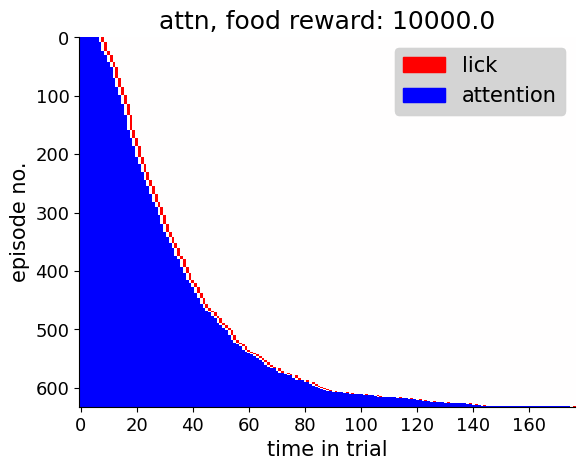

In [25]:
# heatmap trial indicator (att and lick)
plot_no_episodes=9999

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    sortind=np.argsort(trial_len[:plot_no_episodes])

    grid = np.zeros((plot_no_episodes, max(trial_len)+2))

    # att
    plot_data =att_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data =lick_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    
    plt.figure()
    c=plt.imshow(grid[sortind], cmap='bwr', vmin=-1, vmax=1,
                    aspect='auto', interpolation='none')
    # plt.colorbar(c)
    plt.xlabel('time in trial')
    plt.ylabel('episode no.')
    plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    # legend
    # Create Patch objects for the custom legend
    red_patch = Patch(color='red', label='lick')
    blue_patch = Patch(color='blue', label='attention')

    # Create a new legend
    extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
    frame = extra_legend.get_frame()
    frame.set_color('lightgrey')

    # Add the new legend to the existing plot
    plt.gca().add_artist(extra_legend)
    quicksave(f'ep indicator {food_reward_idx}', modelname)
    plt.show()


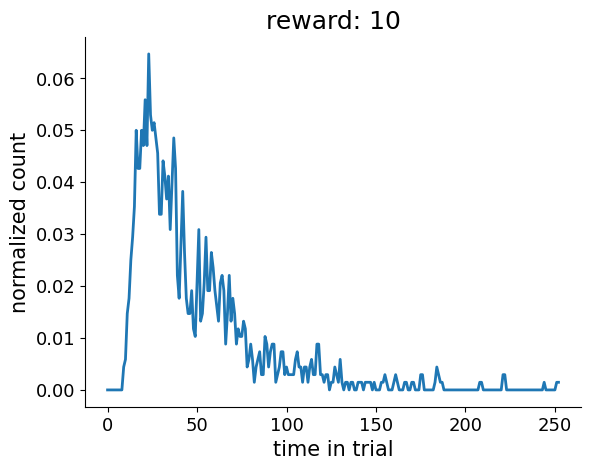

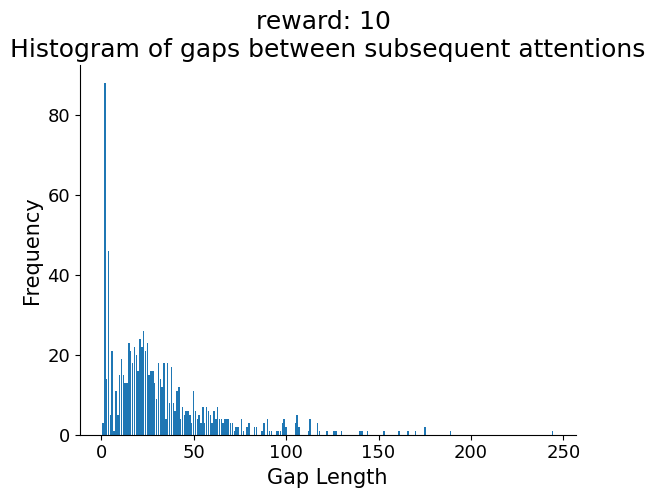

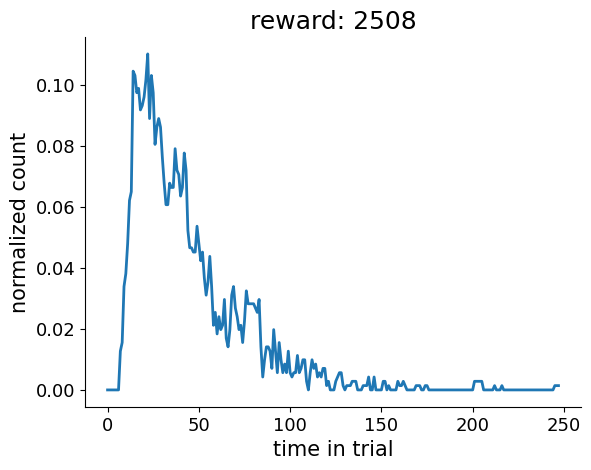

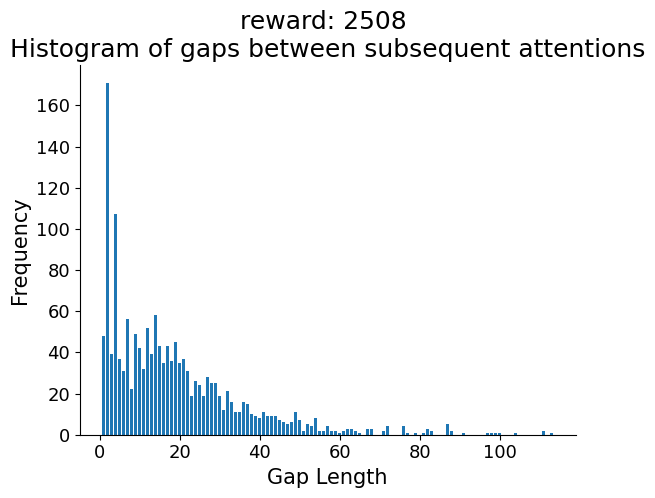

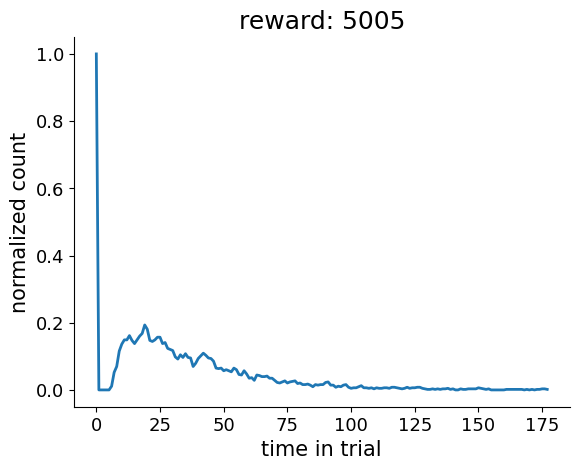

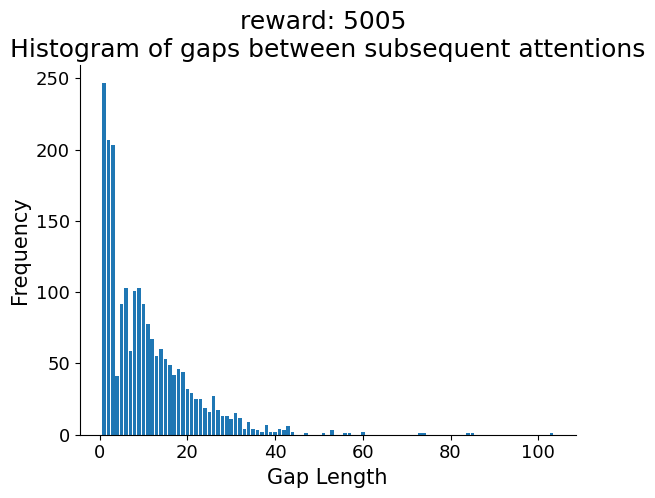

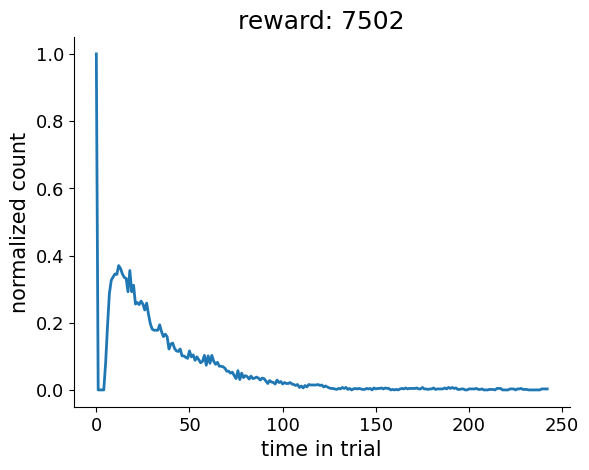

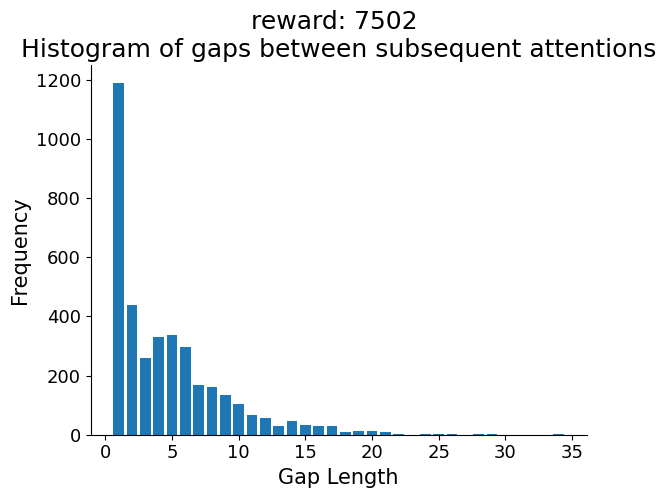

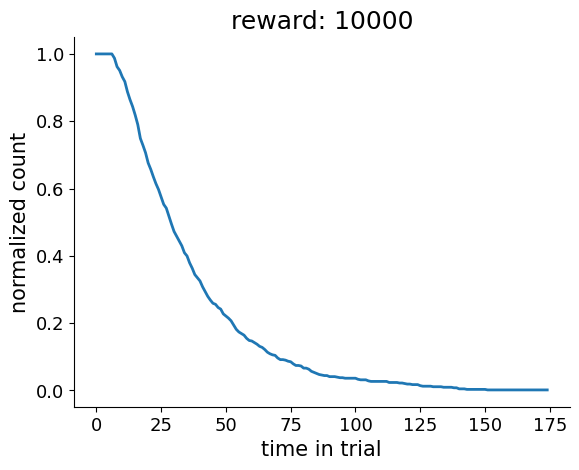

ValueError: max() arg is an empty sequence

<Figure size 640x480 with 0 Axes>

In [36]:
# att time
for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    title=f'reward: {food_reward_list[food_reward_idx]:.0f}'
    if len(att_time_list[0])>0:
  
  

        data=att_time_list
        plt.figure()
        plt.plot(np.sum(pad_zero_attention(data), axis=0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plt.figure()
        histogram = gap_histogram_all_rows(pad_zero_attention(data))
        plt.bar(histogram[1][:-1], histogram[0], width=0.8, align='center')
        plt.xlabel('Gap Length')
        plt.ylabel('Frequency')
        plt.title(f'{title} \nHistogram of gaps between subsequent attentions')
        plt.show()


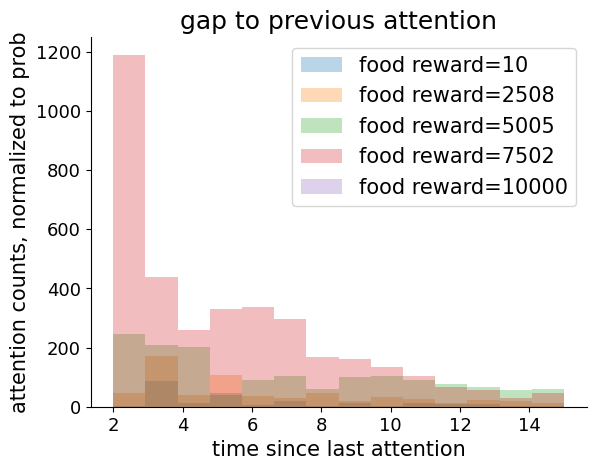

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_78371/1150466086.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(a, fill=False,clip=(0, np.max(a)), bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')


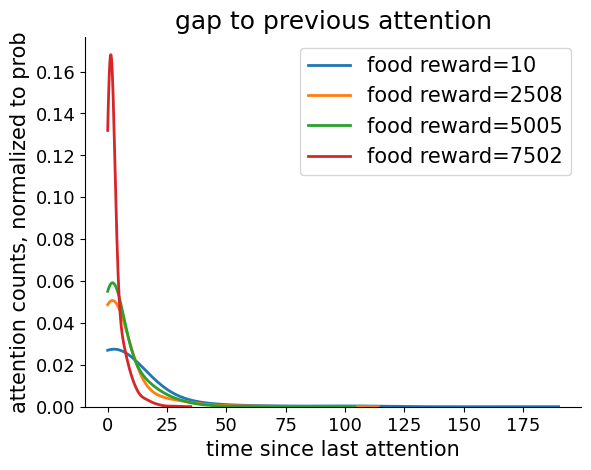

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_78371/1150466086.py:42: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(a, fill=False, clip=(0, np.max(a)),bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')


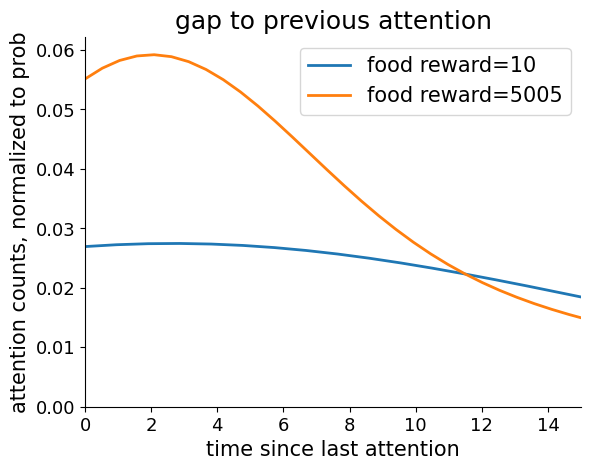

In [27]:
# gap to previous attention block
for food_reward_idx, v in all_reward_res.items():
    # if food_reward_idx in [3,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        if len(att_time_list[0])>0:
            att_gap2previous=[previous_item_gap(a) for a in att_time_list]
            a=np.concatenate(att_gap2previous)
            plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
            # sns.kdeplot(a, fill=False, bw_adjust=0.5)
# plt.ylim(0,1)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
plt.show()

for food_reward_idx, v in all_reward_res.items():
    # if food_reward_idx in [3,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        if len(att_time_list[0])>0:
            att_gap2previous=[previous_item_gap(a) for a in att_time_list]
            a=np.concatenate(att_gap2previous)
            a=a[a>0]
            # plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
            sns.kdeplot(a, fill=False,clip=(0, np.max(a)), bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
# plt.ylim(0,1)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
quicksave('gap full', modelname)
plt.show()

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in [0,2,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        if len(att_time_list[0])>0:
            att_gap2previous=[previous_item_gap(a) for a in att_time_list]
            a=np.concatenate(att_gap2previous)
            a=a[a>0]
            # plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
            sns.kdeplot(a, fill=False, clip=(0, np.max(a)),bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
plt.xlim(0,15)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
quicksave('gap', modelname)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_78371/3598107939.py:16: RuntimeWarning: invalid value encountered in divide
  counts_normalized = counts / np.sum(counts)


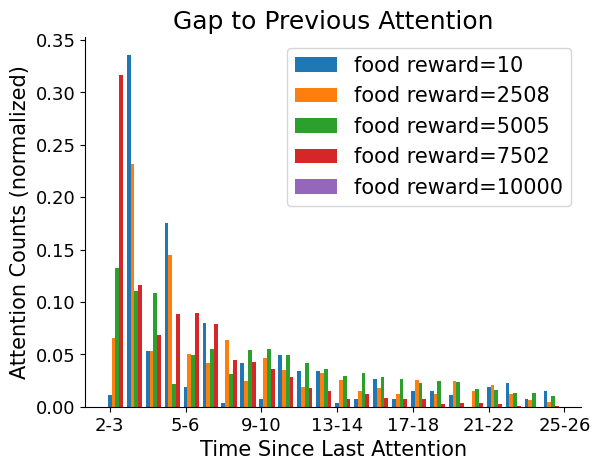

In [28]:
# side by side bar

reward_labels = []
reward_data = []

for food_reward_idx, v in all_reward_res.items():
    # if food_reward_idx in [0, 1, 2]:
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = v
        att_gap2previous = [previous_item_gap(a) for a in att_time_list]
        a = np.concatenate(att_gap2previous)
        
        # Count occurrences of values within bins
        counts, bins = np.histogram(a, bins=np.linspace(2, 25, 25))
        
        # Normalize counts
        counts_normalized = counts / np.sum(counts)
        
        reward_labels.append(f'food reward={food_reward_list[food_reward_idx]:.0f}')
        reward_data.append(counts_normalized)

# Create side-by-side bar chart
fig, ax = plt.subplots()
width = 0.2  # Width of each bar
x = np.arange(len(bins) - 1)

for i in range(len(reward_labels)):
    ax.bar(x + i * width, reward_data[i], width=width, label=reward_labels[i])

# Add labels and legend
ax.set_title('Gap to Previous Attention')
ax.set_ylabel('Attention Counts (normalized)')
ax.set_xlabel('Time Since Last Attention')

# Reduce number of xticks
num_xticks = 6
plt.xticks(np.arange(0, len(bins), step=int(len(bins) / num_xticks)), [f'{int(bin)}-{int(bin+1)}' for bin in bins[::int(len(bins) / num_xticks)]])
    
ax.legend()

plt.show()


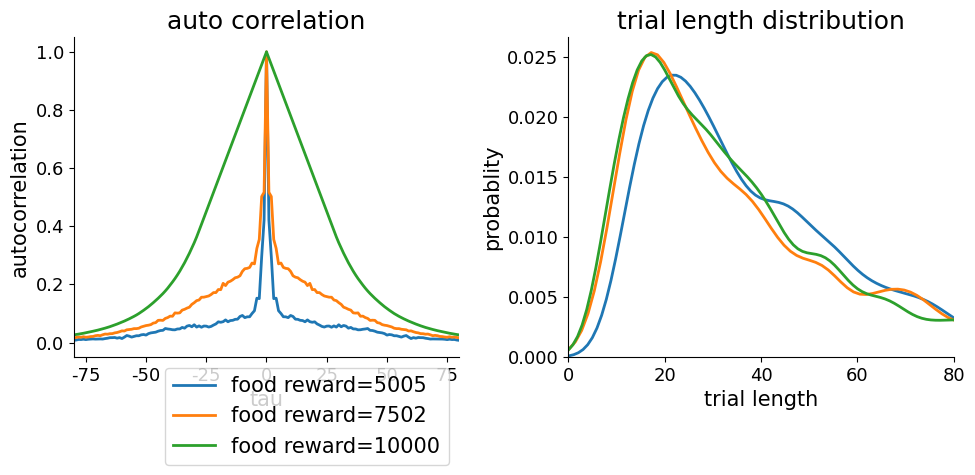

In [29]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
# auto correlation    
for food_reward_idx in [2,3,4]:
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx']==food_reward_idx:
            att_seq_list.append([float(elt[1]) for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    sequences = sorted_list_of_lists[-333:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
    normalized_sequences = []
    max_length = 0
    for sequence in sequences:
        normalized_seq = np.array(sequence)
        if not np.isnan(normalized_seq.any()):
            normalized_sequences.append(normalized_seq)
            max_length = max(max_length, len(normalized_seq))    
        
    padded_sequences = []
    for seq in normalized_sequences:
        padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
        padded_sequences.append(padded_seq)

    autocorrelation_sum = np.zeros(2 * max_length - 1)
    for seq in padded_sequences:
        autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)


    average_autocorrelation = autocorrelation_sum / len(padded_sequences)
    xs=np.arange(0,len(average_autocorrelation),1)
    xs=xs-len(xs)//2
    ax1.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    ax1.set_xlabel('tau')
    ax1.set_ylabel('autocorrelation')
    ax1.set_xlim(-80,80)
    # ax1.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')
    ax1.set_title('auto correlation')
    ax1.legend()

    # ax2.hist([len(a) for a in att_seq_list])
    sns.kdeplot([len(a) for a in att_seq_list], fill=False, bw_adjust=0.5)
    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0,80)
    ax2.set_title('trial length distribution')
    # ax2.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')

ax1.legend(bbox_to_anchor=(1,0))
plt.tight_layout()
# quicksave('autocorr', modelname)
plt.show()

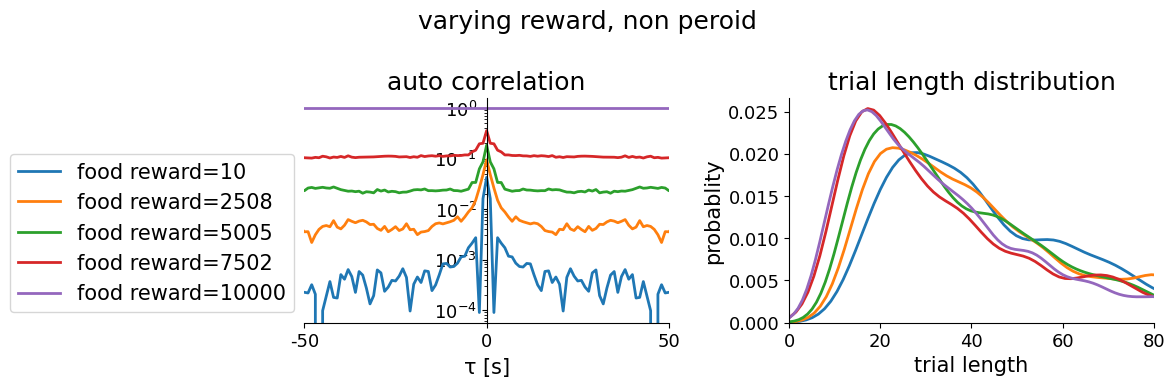

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# auto correlation 
for food_reward_idx in range(len(food_reward_list)):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
                label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2)

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50,50)
    # ax1.set_ylim(0, .03)
    ax1.set_xticks([-50, 0, 50])
    ax1.set_yticklabels([])
    ax1.set_yscale('log')
    # centerax(ax1)
    ax1.spines['left'].set_position('zero')
    quickleg(ax1)
    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

fig.suptitle('varying reward, non peroid')
plt.tight_layout()
quicksave('autocorr', modelname)
plt.show()